Data Wrangling and Exploratory Data Analysis

In [3]:
import pandas as pd
import seaborn as sns
import numpy as np  
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('diabetes_012_health_indicators_BRFSS2015.csv')
df

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


In [5]:
df[df.isna().any(axis=1)]  # Check for NaN values


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income


Not missing values in this data set

In [6]:
df = df.drop_duplicates(keep='first') # drop duplicated rows
df.shape 

(229781, 22)

In [7]:
#Rename a variable
df = df.rename(columns={'AnyHealthcare':'Has_Healthcare'})

In [8]:
# New variable that checks for diabetes as a categorical data type

df['Diabetes_Binary'] = df['Diabetes_012'].replace({0:0, 1:1, 2:1})
df['Diabetes_Binary'] = df['Diabetes_Binary'].astype('category')

# Convert variables to categorical type
df['HighBP']= df['HighBP'].astype('category')
df['HighChol']= df['HighChol'].astype('category')

df['Smoker']=df['Smoker'].astype('category')
df['Sex']= df['Sex'].astype('category')

In [9]:
df.dtypes

Diabetes_012             float64
HighBP                  category
HighChol                category
CholCheck                float64
BMI                      float64
Smoker                  category
Stroke                   float64
HeartDiseaseorAttack     float64
PhysActivity             float64
Fruits                   float64
Veggies                  float64
HvyAlcoholConsump        float64
Has_Healthcare           float64
NoDocbcCost              float64
GenHlth                  float64
MentHlth                 float64
PhysHlth                 float64
DiffWalk                 float64
Sex                     category
Age                      float64
Education                float64
Income                   float64
Diabetes_Binary         category
dtype: object

In [10]:
# smaller dataframe to divide diabetes into 2 groups:
df_no_diabetes = df[df['Diabetes_Binary'] == 0]
df_diabetes = df[df['Diabetes_Binary'] == 1]

In [11]:
df_no_diabetes.shape

(190055, 23)

In [12]:
df_diabetes.shape

(39726, 23)

Exploratory Data Analysis

In [13]:
df['BMI'].describe() #Numerical

count    229781.00000
mean         28.68567
std           6.78636
min          12.00000
25%          24.00000
50%          27.00000
75%          32.00000
max          98.00000
Name: BMI, dtype: float64

From the Descriptive Statistics of the BMI (Body Mass Index)
The mean is around 28.69 which indicates overweight.
Half of the individuals have a BMI below 27.0 and half above.
BMI values vary by about 6.79 from the mean.
The BMI values range from 12.00 to 98.00. 


Text(0.5, 1.0, 'BMI Distribution across observations')

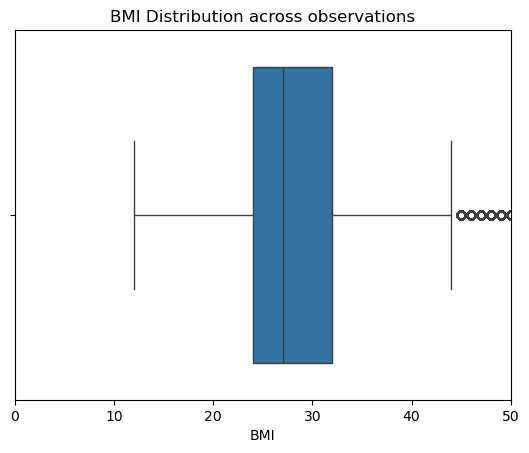

In [18]:
#BMI distribution
sns.boxplot(data = df, x="BMI")
plt.xlim(0, 50)
plt.title('BMI Distribution across observations')

Text(0.5, 1.0, 'BMI Distribution by High Blood Pressure and Diabetes Status')

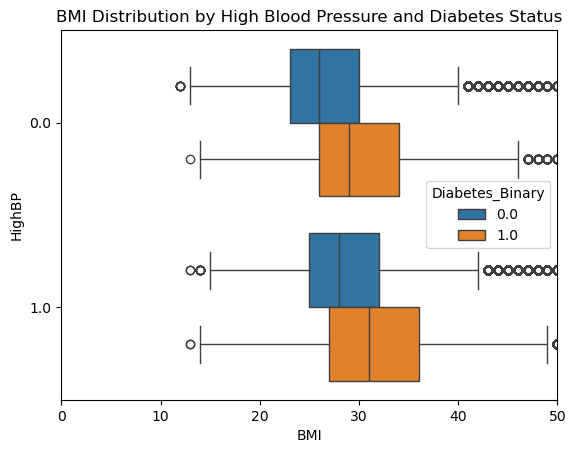

In [17]:
# BMI distribution by blood pressure and diabetes status
sns.boxplot(data = df, x = df['BMI'], y=df['HighBP'], hue =df['Diabetes_Binary'] )
plt.xlim(0, 50)
plt.title('BMI Distribution by High Blood Pressure and Diabetes Status')

The grouped boxplots above indicate that diabetes is associated with higher BMI levels.Additionally, individuals with diabetes have a median BMI higher when high blood pressure is also present.

In [14]:
df['PhysHlth'].describe()

count    229781.000000
mean          4.675178
std           9.046568
min           0.000000
25%           0.000000
50%           0.000000
75%           4.000000
max          30.000000
Name: PhysHlth, dtype: float64

The descriptive statistics of physical health variable (scale 1-30 days)
Mean is 4.68 and its larger than the median which indicates the data may be right skewed
The values have a standard deviation of 9.05
Half of the observations values are 0

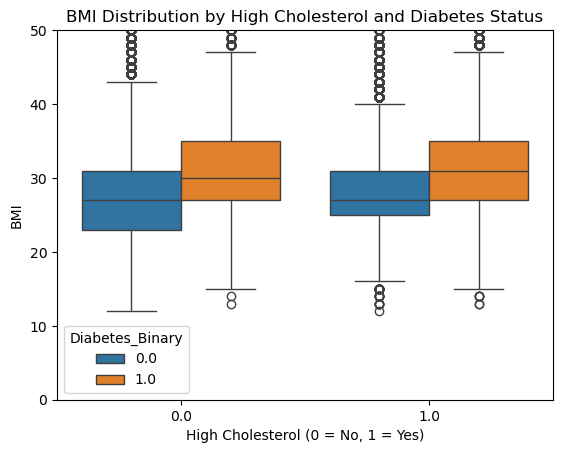

In [19]:
#BMI distribution by high cholesterol and diabetes status
sns.boxplot(data=df, x='HighChol', y='BMI', hue='Diabetes_Binary')
plt.title('BMI Distribution by High Cholesterol and Diabetes Status')
plt.xlabel('High Cholesterol (0 = No, 1 = Yes)')
plt.ylabel('BMI')
plt.ylim(0, 50)
plt.show()

The BMI distribution by HighChol and Diabetes status boxplot displays the data distribution for each group individuals with diabetes and non-diabetes individuals. In both cholesterol groups, individuals with diabetes show a higher median BMI compared to those without.The difference in BMI distributions between high cholesterol and normal groups is relatively small, indicating that cholesterol status does not alter BMI patterns within this dataset.

In [16]:
df['Diabetes_Binary'].value_counts() #Categorical

Diabetes_Binary
0.0    190055
1.0     39726
Name: count, dtype: int64

In [17]:
df['Smoker'].value_counts()

Smoker
0.0    122781
1.0    107000
Name: count, dtype: int64

In [18]:
df.groupby(['Diabetes_Binary'])['BMI'].mean()

C:\Users\AMVel\AppData\Local\Temp\ipykernel_2064\1040025869.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Diabetes_Binary'])['BMI'].mean()


Diabetes_Binary
0.0    28.030528
1.0    31.819967
Name: BMI, dtype: float64

In [19]:
df.groupby(['Diabetes_Binary'])['Age'].mean()

C:\Users\AMVel\AppData\Local\Temp\ipykernel_2064\2710464328.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['Diabetes_Binary'])['Age'].mean()


Diabetes_Binary
0.0    7.824230
1.0    9.341716
Name: Age, dtype: float64

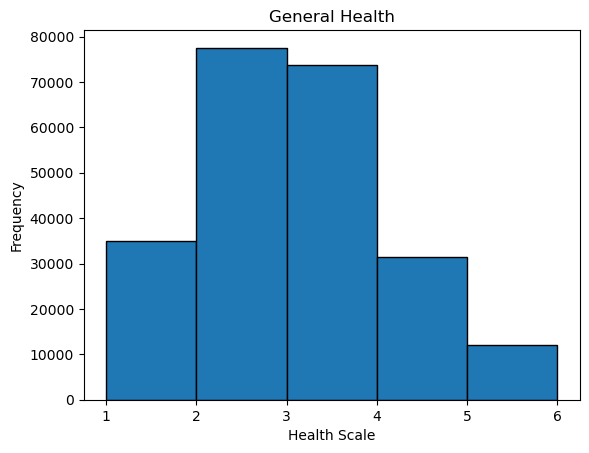

In [20]:
#Distribution of general health
bin_edges = [1, 2, 3, 4, 5, 6]
plt.hist(df['GenHlth'], bins= bin_edges, edgecolor='black')
plt.title('General Health')
plt.xlabel('Health Scale')
plt.ylabel("Frequency")
plt.show()

The general health histogram displays five bins labeled from 1 to 5, where 1 indicates excellent health, 2 very good, 3 good, 4 fair, and 5 poor. This visualization provides an overview of the distribution of health status in the dataset. in future analyses it may be useful to compare the overall health between diabetic and non‑diabetic individuals and explore potential associations between general health and diabetes status.

Text(0.5, 1.0, 'Age Ranges for Diabetes')

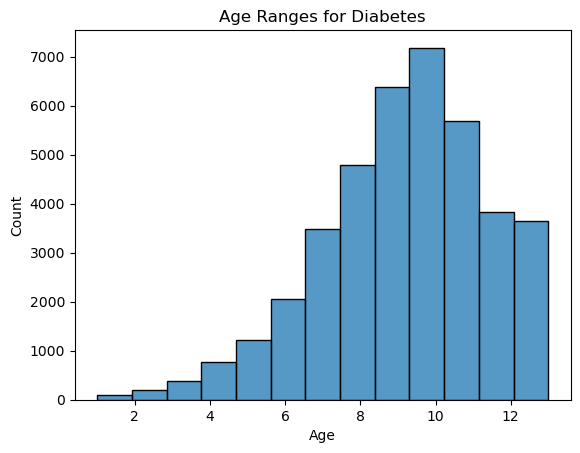

In [21]:
#Age distribution of individuals with diabetes
sns.histplot(data = df_diabetes, x = 'Age',bins=13)
plt.title('Age Ranges for Diabetes')

In [25]:
df_diabetes['Age'].describe() #Numerical

count    39726.000000
mean         9.341716
std          2.373136
min          1.000000
25%          8.000000
50%         10.000000
75%         11.000000
max         13.000000
Name: Age, dtype: float64

The age distribution for individuals with diabetes is left skewed, indicating mean age is lower than the median age.This shows that a larger proportion of diabetic individuals are older in this dataset.

C:\Users\AMVel\AppData\Local\Temp\ipykernel_16260\2107087579.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Diabetes_Binary')['HighBP'].value_counts().unstack().plot(kind='bar')


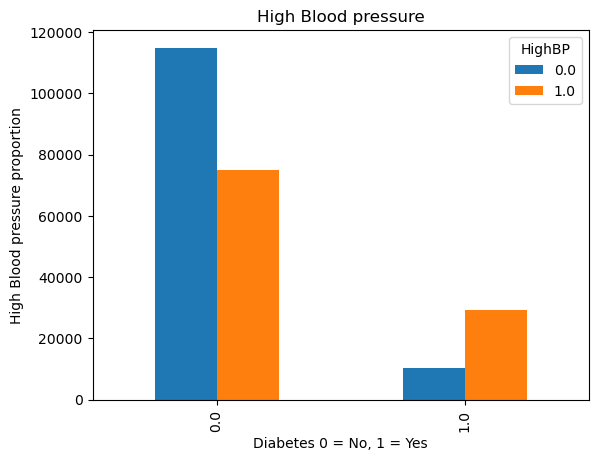

In [22]:
#Proportion of high blood pressure in relation to diabetes status
df.groupby('Diabetes_Binary')['HighBP'].value_counts().unstack().plot(kind='bar')
plt.title('High Blood pressure')
plt.xlabel('Diabetes 0 = No, 1 = Yes')
plt.ylabel('High Blood pressure proportion')
plt.show()

Among the individuals with diabetesgroup, the proportion of high blood pressure is significantly higher. without high blood pressure is greater than the proportion with high blood pressure. This suggests that elevated blood pressure is less prevalent among those without diabetes in this dataset.

C:\Users\AMVel\AppData\Local\Temp\ipykernel_16260\2351913082.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Diabetes_Binary')['Smoker'].value_counts().unstack().plot(kind='bar')


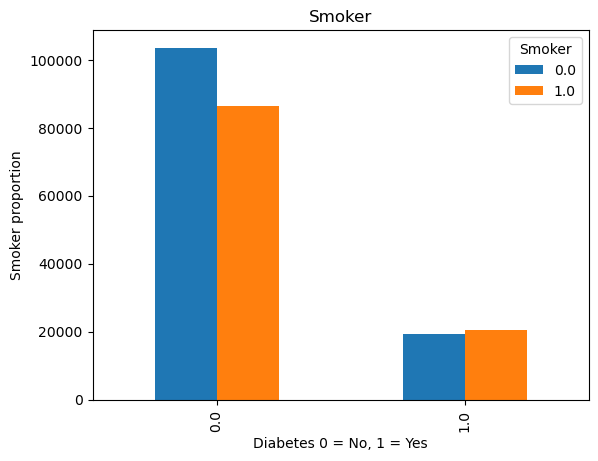

In [23]:
#Proportion of smokers in relation to diabetes status
df.groupby('Diabetes_Binary')['Smoker'].value_counts().unstack().plot(kind='bar')
plt.title('Smoker')
plt.xlabel('Diabetes 0 = No, 1 = Yes')
plt.ylabel('Smoker proportion')
plt.show()

Among individuals with diabetes, the proportion of smokers is slightly higher than that of non‑smokers. In contrast, within the non‑diabetic group, non‑smokers represent a noticeably larger share than smokers. This distinction shows differing smoking patterns between the two populations and may be relevant when interpreting health outcomes or risk factors.

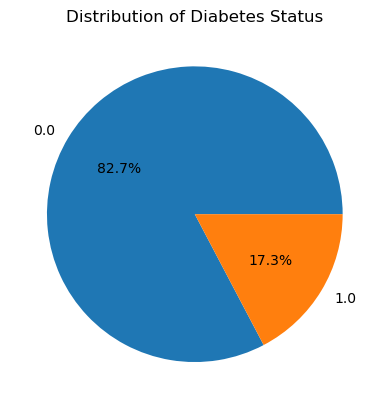

In [24]:
#Distribution of Diabetes across dataset

df['Diabetes_Binary'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)
plt.title('Distribution of Diabetes Status')
plt.ylabel('')
plt.show()

The pie chart displays the distribution of two groups in our dataset: diabetic and non‑diabetic individuals. The visualization shows that the majority of our data comes from non‑diabetic participants. This information may be useful for future analysis, especially when interpreting patterns and comparing proportions between the two groups.

In [31]:
df.to_csv("cleaned_diabetes.csv", index=False)